## Web Scraping Project: Flipkart Mobile Data Analysis and Visualization

- Scraped mobile phone data from Flipkart using BeautifulSoup.
- Extracted product names, prices, descriptions, and ratings.
- Cleaned the dataset by removing duplicates and converting datatypes.
- Saved cleaned dataset into CSV format.
- Performed basic data analysis and visualization using Matplotlib.

In [1]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

In [2]:
headers = {"User-Agent": "Mozilla/5.0"}

Product_Name = []
Prices = []
Description = []
Review = []

for i in range(2,12):
    url = "https://www.flipkart.com/search?q=mobiles+under+50000&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page="+str(i)
    web = requests.get(url, headers = headers)
    #print(web.status_code)
    soup = BeautifulSoup(web.content, "html.parser")
    #print(soup)
    box = soup.find("div" , class_= "QSCKDh dLgFEE")

#taking multiple pages from website
    np = soup.find("a", class_= "jgg0SZ").get("href")
    cnp = "https://www.flipkart.com"+np
    #print(cnp)  
    
    names = box.find_all("div" , class_= "RG5Slk")
    
    for i in names:
        name = i.text
        Product_Name.append(name)
    
        #print(Product_Name)

    prices = box.find_all("div" , class_= "hZ3P6w DeU9vF")

    for i in prices:
        price = i.text
        Prices.append(price)
    
    #print(Prices)

    desc = box.find_all("ul" , class_= "HwRTzP")

    for i in desc:
        description = i.text
        Description.append(description)
    
    #print(Description)

    reviews = box.find_all("div" , class_= "MKiFS6")

    for i in reviews:
        rev = i.text
        Review.append(rev)
    
    #print(Review)

In [3]:
print(len(Product_Name))
print(len(Prices))
print(len(Description))
print(len(Review))

240
240
240
230


In [4]:
#converting data into table form
min_len = min(len(Product_Name), len(Prices), len(Description), len(Review))

df = pd.DataFrame({
    "Product name": Product_Name[:min_len],
    "Prices": Prices[:min_len],
    "Description": Description[:min_len],
    "Review": Review[:min_len]
    })
#print(df)
df

,Product name,Prices,Description,Review
0,"Samsung Galaxy A55 5G (Awesome Iceblue, 256 GB)","₹48,890",12 GB RAM | 256 GB ROM | Expandable Upto 1 TB1...,4.3
1,"OnePlus 13R 5G (Nebula Noir, 256 GB)","₹41,799",12 GB RAM | 256 GB ROM17.22 cm (6.78 inch) Dis...,4.5
2,"vivo T5x 5G (Cyber Green, 128 GB)","₹22,999",6 GB RAM | 128 GB ROM17.17 cm (6.76 inch) Disp...,4.4
3,"vivo T5x 5G (Star Silver, 256 GB)","₹26,999",8 GB RAM | 256 GB ROM17.17 cm (6.76 inch) Disp...,4.4
4,"OnePlus 13R 5g (Astral Trail, 256 GB)","₹44,999",12 GB RAM | 256 GB ROM17.22 cm (6.78 inch) Dis...,4.5
...,...,...,...,...
225,MOTOROLA Edge 60 Fusion 5G (PANTONE Mykonos Bl...,"₹26,999",12 GB RAM | 256 GB ROM | Expandable Upto 1 TB1...,4
226,"Ai+ Pulse 2 (Black, 128 GB)","₹9,999",6 GB RAM | 128 GB ROM | Expandable Upto 1 TB17...,4.7
227,"Samsung Galaxy F70e 5G (Limelight Green, 128 GB)","₹13,999",6 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,3.9
228,"Samsung Galaxy F70e 5G (Spotlight Blue, 128 GB)","₹12,499",4 GB RAM | 128 GB ROM | Expandable Upto 2 TB17...,4.2


In [5]:
#saving dataset into csv file
df.to_csv("flipkart_mobiles.csv", index=False)

## Cleaning Data

In [6]:
#checking null values
df.isnull().sum()

Product name    0
Prices          0
Description     0
Review          0
dtype: int64

In [8]:
# removing symbols for better analysis

df["Prices"] = df["Prices"].str.replace("₹","")
df["Prices"] = df["Prices"].str.replace(",","")
df["Prices"] = df["Prices"].astype(int)

df["Review"] = df["Review"].astype(float)

In [9]:
#checking datatype
df.dtypes

Product name        str
Prices            int64
Description         str
Review          float64
dtype: object

In [10]:
#checking duplicate values
df.duplicated().sum()

np.int64(9)

In [11]:
#removing duplicate values
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [12]:
#sorting table by prices and visualizing
df.sort_values(by="Prices" , ascending=False).head(10)

,Product name,Prices,Description,Review
203,"Apple iPhone 17 (Black, 256 GB)",78900,256 GB ROM16.0 cm (6.3 inch) Super Retina XDR ...,4.6
212,"Apple iPhone 16 (Pink, 128 GB)",66900,128 GB ROM15.49 cm (6.1 inch) Super Retina XDR...,4.2
221,"Apple iPhone 16 (Black, 128 GB)",66900,128 GB ROM15.49 cm (6.1 inch) Super Retina XDR...,4.3
213,"Apple iPhone 16 (Teal, 128 GB)",66900,128 GB ROM15.49 cm (6.1 inch) Super Retina XDR...,4.4
219,"Apple iPhone 16 (White, 128 GB)",66900,128 GB ROM15.49 cm (6.1 inch) Super Retina XDR...,4.3
208,"Apple iPhone 15 (Black, 128 GB)",56900,128 GB ROM15.49 cm (6.1 inch) Super Retina XDR...,4.2
21,"Xiaomi 14 CIVI (Panda White, 512 GB)",54999,12 GB RAM | 512 GB ROM16.64 cm (6.55 inch) Dis...,4.4
66,"Samsung Galaxy A57 5G (Awesome Icyblue, 256 GB)",49999,8 GB RAM | 256 GB ROM17.02 cm (6.7 inch) Full ...,4.5
45,"Motorola Edge 30 Fusion (Cosmic grey, 128 GB)",49999,8 GB RAM | 128 GB ROM16.64 cm (6.55 inch) Full...,4.5
17,"vivo V70 (Lemon Yellow, 256 GB)",49999,8 GB RAM | 256 GB ROM16.74 cm (6.59 inches) Fu...,4.5


## Data Visualization

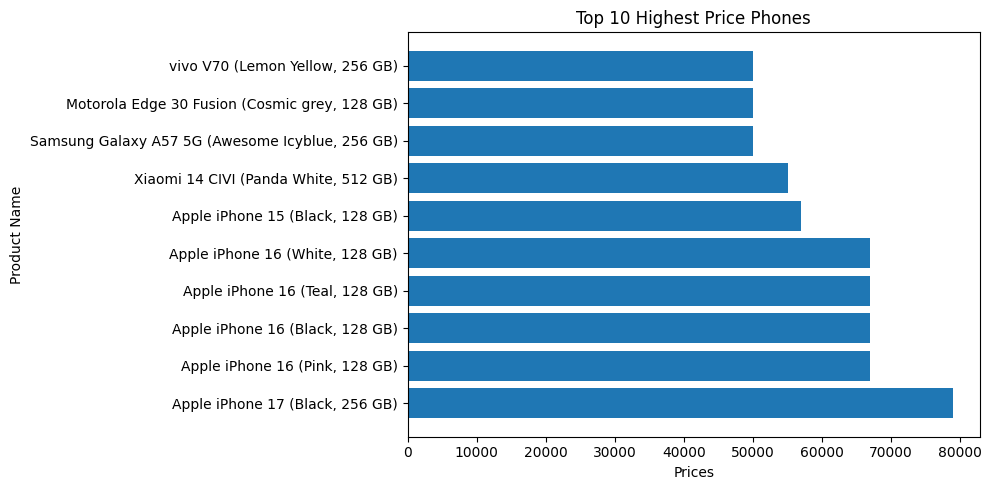

In [13]:
import matplotlib.pyplot as plt

Top10 = df.sort_values(by="Prices" , ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(Top10["Product name"] , Top10["Prices"])

#plt.xticks(rotation=90)
plt.xlabel("Prices")
plt.ylabel("Product Name")
plt.title("Top 10 Highest Price Phones")
plt.tight_layout()
plt.show()

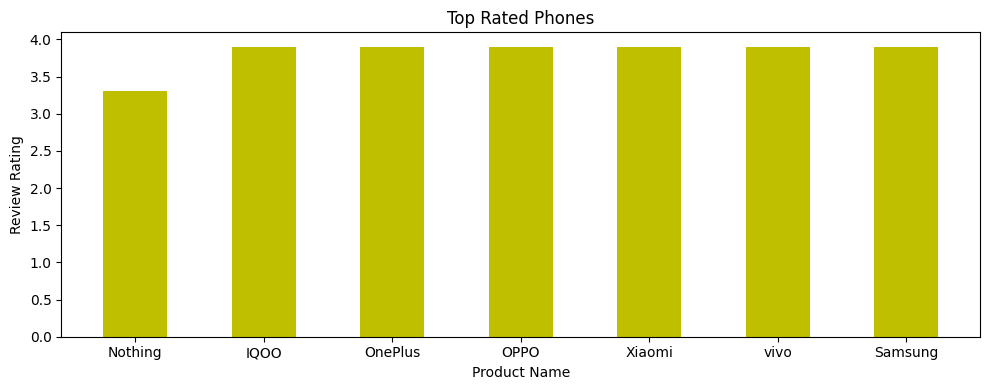

In [14]:
TopRated = df.sort_values(by="Review", ascending=True).head(10)

plt.figure(figsize=(10,4))

plt.bar(TopRated["Product name"].str.split().str[0] , TopRated["Review"], width=0.5 , color="y")

plt.xlabel("Product Name")
plt.ylabel("Review Rating")

plt.title("Top Rated Phones")

plt.tight_layout()

plt.show()

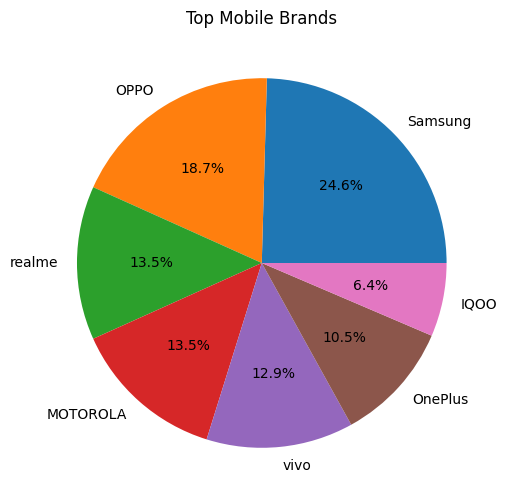

In [15]:
df["Brand"] = df["Product name"].str.split().str[0]

brand_count = df["Brand"].value_counts().head(7)

plt.figure(figsize=(6,6))

plt.pie(brand_count, labels=brand_count.index, autopct='%1.1f%%')

plt.title("Top Mobile Brands")

plt.show()

In [17]:
df.to_csv("cleaned_flipkart_mobile_data.csv", index=False)